# Module 4 — The FUR Regulon: Literature to Motif

**Lab context:** *E. coli* K-12 | bowtie2 | MEME Suite | Biopython | FUR transcription factor

---

This module connects a published dataset to a motif analysis pipeline:

1. **Understanding the literature** — read a real ChIP-exo paper and extract biological context.
2. **RNA-seq paired-end alignment** — the foundational read-alignment step (extends Module 3), applied to the study's transcriptome data.
3. **Motif discovery with MEME** — given a set of genomic sequences, MEME finds overrepresented patterns.
4. **Sequence extraction with Biopython** — pull binding-site sequences from the *E. coli* K-12 genome by coordinate.
5. **TSS distance analysis** — compute distances between binding sites and transcription start sites.

---

**Learning objectives:**
- Understand a real ChIP-exo study and the data it produced
- Use Biopython to extract genomic sequences by coordinate from a public dataset
- Run MEME and interpret motif output (E-value, logo shape)
- Download and align **paired-end RNA-seq** reads with bowtie2, and turn them into a GFF track
- Compute TSS distances as a downstream regulatory analysis


## Background: Transcription Factors, FUR, and Motifs

### What is a transcription factor?

A **transcription factor (TF)** is a protein that binds to specific short DNA sequences near a gene and controls whether that gene gets expressed. Think of it as a light switch wired into the chromosome: when the TF binds, it turns the gene on (or off). Bacteria like *E. coli* use hundreds of TFs to respond to changing conditions — temperature, nutrients, stress.

### What is FUR?

**FUR** (Ferric Uptake Regulator) is one of the most-studied TFs in *E. coli*. Its job is to sense how much iron is available in the cell and adjust gene expression accordingly:

- **Iron-replete (plenty of iron):** FUR binds its target sites and *represses* iron-uptake genes (no need to import more iron)
- **Iron-depleted (low iron):** FUR releases its targets, allowing iron-uptake genes to be expressed

Iron is essential for most cellular processes but toxic in excess — FUR is the cell's main iron thermostat. It controls roughly 90 genes in *E. coli*.

### What is a regulon?

A **regulon** is the complete set of genes controlled by one TF. The FUR regulon = all genes whose expression is directly regulated by FUR binding. Mapping a regulon requires knowing *where* FUR binds — which is exactly what ChIP-exo (Module 3) measures.

### What is a DNA binding motif?

When a TF binds DNA, it doesn't land randomly — it recognizes a specific short sequence pattern, typically 15–20 bp. This pattern is the TF's **binding motif**. For FUR it's called the **Fur box**. If you look at all the genomic sites where FUR binds, you expect to find the same short sequence pattern repeated at each one.

**MEME** is the tool that discovers this pattern automatically: it takes a set of sequences (your ChIP-exo peaks) and finds the motif that appears more often than chance would predict.

---

## 1. The FUR Regulon — Seo et al. 2014

The FUR binding site data used in this module comes from a real published study:

> **Seo SW, Kim D, Latif H, O'Brien EJ, Szubin R, Palsson BO (2014)** — *Deciphering Fur transcriptional regulatory network highlights its complex role beyond iron metabolism in Escherichia coli* — ***Nature Communications*** 5:4910.
> PMID: 25222563 | PMC: https://pmc.ncbi.nlm.nih.gov/articles/PMC4167408/ | DOI: 10.1038/ncomms5910 | GEO: **GSE54901**

The study used ChIP-exo to map Fur-binding sites genome-wide across different iron conditions.

**Two different things live in two different places — this matters for the exercises:**
- **Raw ChIP-exo signal** is deposited at GEO (**GSE54901**), as per-base *coverage tracks* (one row per genomic position). This is what you align to and visualize — it is **not** a list of binding sites.
- **The discrete binding-site coordinates** (the 144 called peaks, with their target genes and signal strengths) are in the paper's **Supplementary Data** table (an Excel file), *not* on GEO. This table is the input to your MEME analysis in Exercise 5.


### Exercise 1 — Understand the paper and its data

Read Seo et al. 2014 (PMC4167408) — or use Claude Code to help you understand it — and write a **3-sentence summary** in the cell below covering:
- What experiment was done, in what organism, and under what conditions
- How many FUR binding sites were identified and what regulatory modes (categories) were described
- Where the discrete binding-site coordinates are found (which supplementary table), and — separately — what kind of data GEO GSE54901 actually holds

In Exercise 5 you will download the **supplementary binding-site table** from the paper and use its coordinates as the input to motif discovery.


> **Answer**
>
> *Your 3-sentence summary here.*
> 
>
> 1. what to do :  본 연구의 목적은 E. coli의 Fur 조절 네트워크를 genome-scale에서 규명하는 것이다. 이를 위해 Fur와 RNA polymerase를 대상으로 ChIP-exo를 수행하여 Fur 결합 부위와 전사 영역을 확인하고, 철 충분 및 철 결핍 조건에서 WT와 Δfur 균주의 strand-specific RNA-seq 데이터를 비교하여 유전자 발현 변화를 분석하였다. Fur 결합 정보와 발현 정보를 토대로 Fur이 직접 조절하는 regulon을 재구성하고, 철 조건에 따른 holo-Fur 중심의 전사 억제 및 활성화와 철 결핍 조건에서의 Fur 조절 양상을 확인하였다.
>   실험에는 *E. coli* K-12 MG1655와 그 유도체가 사용되었다. Lamda Red 매개 상동재조합을 이용해 Fur-8myc 균주와 Δfur 균주를 제작했으며, Fur-8myc 균주는 Fur ChIP-exo에, Δfur 균주는 Fur에 의한 발현 조절을 확인하기 위한 전사체 비교에 사용하였다. Iron-repleted cond에선 FeCl₂를 첨가했고, depleted 에서는DPD를 첨가해 이용 가능한 철을 감소시켰다.
> 
> 2. FUR의 binding site는 총 iron starvation cond에서 59개, iron replet cond에선 118개가 나왔다. starvation cond에서 나온 59개 중 58개는 replet cond와 같은 위치에서 확인되었다. 논문에선, Different mode of FUR regulation 으로 apo- & holo- FUR activation, holo- FUR repression이 제시되었다.
>   - holo-FUR repessor : iron-repleted 환경에서 Fe2+-Fur이 조절 영역에 결합하여 iron uptake관련 유전자의 전사를 억제
>   - holo-FUR activator : iron-repleted 환경에서 Fe2+-Fur이 조절 영역에 결합하여 관련 유존자의 전사를 증가
>   - apo-FUR activator : iron-depleted 환경에서 apo-Fur이 표적 유전자의 조절영역에 직접 결합하여 전사를 증가(Fe2+결합체가 아닌 Fur)
>
>
> 3. Binding site의 개별 좌표(coordinate)는 Fig. 2a와 Supplementary Data 1에 나타나있다. GEO GSE54901은 Fur/RNAP ChIP-exo와 RNA-seq의 raw data를 담고 있음
> 


## 2. RNA-seq: Paired-End Alignment with `bowtie2`

So far you've worked with **ChIP-exo** data (single-end). The same Fur study also produced **RNA-seq** data — a *second data type* and your first **paired-end** alignment.

Paired-end sequencing reads **both ends** of each DNA fragment, producing two FASTQ files per sample (`_1` = R1, `_2` = R2). `bowtie2` aligns them together (`-1`/`-2`), using the known fragment-size range to place reads more accurately than single-end. In this section you'll download an RNA-seq sample, align it paired-end, and turn it into a GFF — the same pipeline shape as Module 3, but for a new data type.

**Data:** the RNA-seq sub-series of the Fur study is **GEO GSE54900** (same paper, *Nature Communications* 5:4910). In the original lab workflow the paired-end sample `SRR1168133` was aligned with `bowtie2 --very-fast -X 1000 -3 3` (paired-end), then sorted and converted to GFF with `makegff.py`.


### Exercise 2 — Run a paired-end RNA-seq alignment

**Step 1 — Get a paired-end RNA-seq sample.**
Use Claude Code to navigate to the RNA-seq series and pick one paired-end sample:
```
https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE54900
```
Ask Claude Code to help you:
1. Find a **paired-end** RNA-seq run in GSE54900 and get its SRR accession.
2. Download it with `fastq-dump --split-files <SRR>` (or `fasterq-dump`) — paired-end gives you **two** files, `<SRR>_1.fastq` and `<SRR>_2.fastq`.

**Step 2 — Align paired-end.**
Reuse the *E. coli* K-12 bowtie2 index you built in Module 3. Run a **paired-end** alignment — note the `-1`/`-2` inputs (not a single `-U`):
```bash
bowtie2 --very-fast -X 1000 -3 3 -p 2 \
    -x <index_prefix> \
    -1 <SRR>_1.fastq -2 <SRR>_2.fastq \
    -S <SRR>.sam
```
Then `samtools view -bS` → `samtools sort` → `samtools index`, exactly as in Module 3.

**Step 3 — Make a GFF for the RNA-seq data.**
Run the lab's provided `makegff.py` (at the repo root, the same script Module 3's pipeline used) on the sorted BAM to produce a coverage GFF. **This is RNA-seq, so add `--flip`** — RNA-seq reads report the strand *opposite* the transcript they came from, and `--flip` corrects the strand assignment (for ChIP-exo in Module 3 you omitted it):
```bash
python makegff.py --separate_strand --flip data/reference/<SRR>.sorted.bam data/reference/rnaseq.gff
```
This GFF loads into **MetaScope** alongside the gene annotation to visualize transcription — the same way you visualized the ChIP-exo track. Because `makegff.py` hardcodes `NC_000913` in column 1, it lines up with the annotation automatically.

**Step 4 — Explain the flags.** In the Answer cell, write a **one-sentence explanation for each** flag below (focus on *why*, not just mechanics), drawing on what you saw when you ran the alignment:
- `-X 1000` (maximum fragment/insert size — a paired-end-only flag)
- `-3 3` (3′ trimming)
- `--no-mixed` and `--no-discordant` (paired-end concordance)

Also answer: **why is `-X` meaningless for the single-end ChIP-exo alignment in Module 3, but important here?** what would go wrong downstream if you forgot `--no-discordant`? And: **why does the RNA-seq `makegff.py` need `--flip` when the ChIP-exo one didn't?**

> **Single-end vs paired-end:** Module 3 aligned ChIP-exo reads with a single `-U` input. Here you use `-1`/`-2`. If you accidentally pass paired files to `-U`, bowtie2 treats them as unpaired and every `-X`/concordance flag is silently ignored — a common and quiet mistake.

Write your working pipeline in the code cell below (or run it in the terminal and paste the commands here).


In [ ]:
%%bash
# Step 1: Download the paired-end RNA-seq sample (fastq-dump --split-files -> _1.fastq / _2.fastq)
# GSE54900 -> SRP037711 -> SRX469838 (WT with Fe, replicate 1) -> SRR1168133 (paired-end, 10,848,313 spots)
/opt/sratoolkit/bin/prefetch SRR1168133 -O ../data/reference/
/opt/sratoolkit/bin/fastq-dump --split-files --gzip -O ../data/reference/ ../data/reference/SRR1168133/SRR1168133.sra
rm -rf ../data/reference/SRR1168133
# split files 이용해서 SRR1168133_1/_2 분리해서 생성

# Step 2: Align paired-end reads, reusing the Module 3 bowtie2 index (-1/-2, not -U)
bowtie2 --very-fast -X 1000 -3 3 -p 2 --no-mixed --no-discordant \
    -x ../data/reference/NC_000913.3 \
    -1 ../data/reference/SRR1168133_1.fastq.gz -2 ../data/reference/SRR1168133_2.fastq.gz \
    -S ../data/reference/SRR1168133.sam
# overall alignment rate: 94.10% (--no-mixed --no-discordant 추가 후: mixed/discordant 정렬 제외, concordant pair만 남김)
# bowtie2 이용해서 정렬, 이때 fragment에 길이 제한을 설정, 또한 read의 3'말단에 3bp를 잘라내고 정렬(Illumnia adapter trimming)
# --no-mixed --no-discordant: concordant하게 붙지 못한 pair를 mate 단독으로(mixed) 붙이거나
#  비정상 배치(discordant)로 붙이는 것을 막아, RNA-seq coverage에 신뢰도 낮은 정렬이 섞이지 않도록 함

# Step 3: SAM -> sorted, indexed BAM (samtools view / sort / index)
samtools view -bS ../data/reference/SRR1168133.sam > ../data/reference/SRR1168133.bam
samtools sort ../data/reference/SRR1168133.bam -o ../data/reference/SRR1168133_sorted.bam
samtools index ../data/reference/SRR1168133_sorted.bam

# Step 4: Run makegff.py on the sorted BAM to make the RNA-seq coverage GFF
# Uses the repo-root makegff.py (argparse-based, supports --separate_strand);
python ../makegff.py --separate_strand --flip --log_scale ../data/reference/SRR1168133_sorted.bam ../data/reference/rnaseq.gff
# 발현량 비교 시 score값이 너무 큰 부분들이 존재해서 log scale로 변경

# --- 발현량 비교를 위한 Iron-depleted cond 버전 ---
/opt/sratoolkit/bin/prefetch SRR1168135 -O ../data/reference/
/opt/sratoolkit/bin/fastq-dump --split-files --gzip -O ../data/reference/ ../data/reference/SRR1168135/SRR1168135.sra
rm -rf ../data/reference/SRR1168135

bowtie2 --very-fast -X 1000 -3 3 -p 2 --no-mixed --no-discordant \
    -x ../data/reference/NC_000913.3 \
    -1 ../data/reference/SRR1168135_1.fastq.gz -2 ../data/reference/SRR1168135_2.fastq.gz \
    -S ../data/reference/SRR1168135.sam

samtools view -bS ../data/reference/SRR1168135.sam > ../data/reference/SRR1168135.bam
samtools sort ../data/reference/SRR1168135.bam -o ../data/reference/SRR1168135_sorted.bam
samtools index ../data/reference/SRR1168135_sorted.bam

python ../makegff.py --separate_strand --flip --log_scale ../data/reference/SRR1168135_sorted.bam ../data/reference/rnaseq_depleted.gff


> **Answer**
>
> **`-X 1000`:** 
> : paired end는 DNA fragment 양 끝 R1/R2에서 읽은거라, genome에 매핑된 두 위치 사이의 거리가 곧 원래 DNA fragment의 size를 의미한다. -X는 이 size에 제한을 둬서 size가 너무 큰 경우 fragment로 인지하지 않도록 설정한다.
>
> **`-3 3`:**
> : 논문에서 사용된 Illmnia 계열의 read는 RNA sequencing이 진행될 수록 fragment의 말단 부분에 오류가 생길 확률이 커지므로, 말단의 3bp를 제외하고 정렬하는 방식을 이용하기 위해 사용되었다.
>
> **`--no-mixed` / `--no-discordant`:**
> : 정상적인 경우 R1/R2 mate pair가 genome 상에서 예상되는 방향&거리로 함께 붙는데, mate가 없는 경우, bowtie2는 이를 개별 정렬을 한다. 이를 막기 위해 --no mixed는 pair로 정렬되지 않았을 때, R1/R2를 single-end처럼 재정렬하지 않고, --no-discordant는 mate가 정렬되더라도, 예상 방향이나 거리조건을 벗어나면 결과에 포함시키지 않도록 설정한다.
>
> **Why `-X` matters here but not in Module 3 (single-end):** module3에선 single-end read파일을 지정하는 플래그인 -U를 이용해서 정렬하였으므로 fragment로 볼 수 있는 부분이 없어서 -X를 쓰는 것이 무의미하다.
>
> **What goes wrong without `--no-discordant`:** *Your answer.*
> : -X 1000은 concordant 정렬을 찾는 과정에서만 적용되는 제약이라, discordnat 정렬에는 이 제약이 적용되지 않는다(discordant 정렬의 경우 양쪽 mate가 각각 정렬은 됐지만, mate를 같이 보았을 때, 예상 방향 혹은 -X의 범위를 벗어난 경우 문제가 된다). --no-discordant가 없으면 비정상 Pair까지 결과에 포함되어 최종 결과에 노이즈가 섞여 신뢰도가 떨어질 수 있다.
>
> **`-flip`이 chip exo에서는 필요 없는 이유 :** : 일반 RNA-seq는 cDNA의 두번째 가닥을 시퀀싱해서 read가 원본의 반대 가닥으로 나오므로, 이를 뒤집어야 하지만 Chip-Exo는 exonuclease가 붙은 DNA가닥을 그대로 읽어서 뒤집을 필요가 없다.
> * mate : paired-end sequencing에서 한 DNA fragment의 양 끝을 읽은 R1/R2 read 한 쌍.

## 3. How MEME Works

### What problem does MEME solve?

You have 90 genomic sequences — one around each FUR binding site. If FUR binds a specific sequence pattern (the Fur box), that pattern should appear in most of your sequences. But you don't know in advance *what* the pattern looks like or exactly *where* in each sequence it sits.

**MEME** (Multiple Em for Motif Elicitation) finds overrepresented sequence patterns in a set of input sequences without knowing what to look for. It uses an algorithm called Expectation-Maximization (EM) to iteratively refine a motif model until it fits the data as well as possible.

### What is an E-value?

The **E-value** answers: *"How many times would I expect to find a motif this good by random chance in a dataset this size?"*

- E-value of 10⁻²⁰ → extremely unlikely by chance → strong, real motif
- E-value of 1.5 → you'd expect to see this pattern 1–2 times by chance → likely noise

For a real TF binding motif like the Fur box, expect E-values well below 10⁻¹⁰. If your top motif has an E-value above 0.01, something may be wrong with your input sequences (wrong coordinates, wrong organism, mixed conditions).

Use Claude Code to understand how the EM algorithm works and what the E-value measures before running MEME.

### Exercise 3 — Understand MEME in your own words

Use Claude Code to explore the MEME algorithm and E-value interpretation. Then write a **3-sentence summary in your own words** — not copied from Claude's output, but re-stated in your own understanding.

> Focus on: what problem EM is solving, what E-value measures, and why motif width matters.

> **Answer**
>
> MEME는 두가지 문제를 해결해야하는데, 1. motif가 어떤 서열 패턴인지 2. 각 입력 서열에서 motif가 어디에 위치하는지 이다. 이는 한번에 해결할 수 없으므로, EM(Expectation-Maximization)은 이를 반복적으로 갱신하며 답에 수렴시키는 방법이다.
>
> E-value는 현재 데이터셋과 같은 크기의 무작위 데이터에서, 관찰된 motif와 같거나 혹은 더 큰 점수의 motif가 몇 개나 발견될 것으로 예상되는지에 대한 값이다. E-value가 작을수록 우연히 발견될 가능성이 낮다는 뜻이고, 이는 곧 E-value가 낮다면 단순 우연이 아닌 생물학적으로 의미가 있는 공통 서열을 발견했음을 의미한다.
> 
> MEME는 motif의 width를 모르는 상태에서 시작하기 때문에, 만일 폭이 너무 좁거나 넓으면 각각 실제 binding site의 일부가 누락되거나 결과에 노이즈가 섞일 수 있는 문제가 있어서 적정 범위 안에서 최적 폭을 찾는다. 본 논문에선 FUR binding site를 고려하여 21bp로 폭을 설정하였다.

### Exercise 4 — Conceptual prediction (answer before asking Claude)

**Without asking Claude Code first:** predict what the MEME output would look like for each of these two inputs:

(a) 10 **random** 200 bp genomic sequences from *E. coli* K-12  
(b) 10 **real FUR binding site** sequences (±50 bp around known sites)

For each case, predict: approximate E-value range, whether a clear motif logo would appear, and what width you would expect.

Write your prediction below. Then verify your reasoning with Claude Code and note where you were right or wrong.

*Your prediction here (before checking with Claude Code).*
>
> a) 총 2000개의 bp에서 공통 motif를 찾아야 한다. *E.coli* K-12에서 얻은 10개의 genomic sequence는 특정 기준을 가지고 추출한 random sequnce가 아니기에, 공통 motif가 나올 확률은 적을 것이고, 그렇기에 E-value값은 비교적 클 것이다. 또한, sequnce logo는 불명확하고 motif width도 일정하지 않을 것이다.
>
> b) a에 비해 길이가 50bp정도로 알고 있는 10개의 FUR binding site의 경우, 서열의 크기도 작고 기준도 있으므로 공통 motif가 나올 확률은 더 높을 것이고, 따라서 E-value 또한 a에 비해 더 작은 값이 나올 것이다. motif logo는 분명하게 나올 것이라 생각되고 motif width도 a에 비해 일정한 크기로 나올 것이다.
---

*Verification notes (after checking with Claude Code):*
>
> (a) 10 random 200bp sequences
> - E-value range: 유의하지 않음, 대략 1
> - Motif logo: 뚜렷한 로고 없음 — EM이 억지로 가장 적절한 모티프 하나는 출력하지만 각 위치의 information content가 낮아 글자 높이가 낮고 흐릿한 로고가 나옴
> - Width: 한 번의 MEME 실행은 minw~maxw 범위 안에서 하나의 고정된 width로 수렴함
>
> (b) 10 real FUR binding sites (±50bp)
> - E-value range: 유의함. 표본이 10개로 적어 논문 전체 144개를 썼을 때 나오는 값(1e-50 이하)만큼 극단적이지는 않지만, 대략 1e-5 ~ 1e-15 수준으로 예상
> - Motif logo: 뚜렷하게 나타남 — Fur box 특유의 AT-rich 역방향 반복(inverted repeat) 패턴
> - Width: 실제 Fur box 길이인 약 15~19bp 근방으로 수렴 (논문에서 21bp로 설정한 것과 같은 범위)
>


## 4. Extracting Sequences with Biopython

The Fur-binding site coordinates come from the **Supplementary Data table of Seo et al. 2014** (an Excel file you download from the paper in Exercise 5), which lists each site's `ChIP-exo Start` / `ChIP-exo End`. Use Biopython to extract DNA sequences from the *E. coli* K-12 reference FASTA at those coordinates. Handle strand correctly — reverse-complement sequences on the minus strand.


### Exercise 5 — Fetch the data and write the sequence extraction script

**Step 1 — Get the binding-site table with Claude Code:**
The discrete Fur binding sites are in the **Supplementary Data** of the Nature Communications paper, not on GEO. Give Claude Code the article page and ask it to locate and download the supplementary table:

```
https://www.nature.com/articles/ncomms5910
```

Ask Claude Code to:
1. Find the **Supplementary Data** file that contains the Fur ChIP-exo **binding sites** (target gene, `ChIP-exo Start`, `ChIP-exo End`, binding condition, S/N ratio) and download it into `data/reference/`. *(It is an Excel `.xlsx` file — the same one used in the original lab tutorial.)*
2. Download the *E. coli* K-12 reference FASTA into `data/reference/NC_000913.fasta` (same file as Module 3 — skip if already present).

**Step 2 — Read the table.** It has a title row above the real header, so read it with the header on the **second** row:
```python
import pandas as pd
df = pd.read_excel("data/reference/<supplementary_file>.xlsx", header=1)
df = df.dropna(subset=["Peak"])          # keep rows that are actual binding sites
```
Columns include: `Transcription Unit`, `Peak` (a peak **ID label** like `P1`, `P2` — *not* a score), `ChIP-exo Start`, `ChIP-exo End`, `Binding Condition` (`R` = iron-replete, `S` = iron-depleted, `R/S` = both), `S/N ratio` and `Significance (p-value)` (these are the strength/score fields), and `Distance to TSS`. Filter to the **iron-replete** sites with `Binding Condition` containing `R`.

**Step 3 — Write a Biopython script that:**
1. Reads the binding-site coordinates from the table (iron-replete sites).
2. Loads the reference FASTA.
3. Extracts sequences ±50 bp around each binding site center (center = midpoint of `ChIP-exo Start`/`End`).
4. Handles strand correctly if a strand is available (reverse complement for `-`).
5. Writes a FASTA file (`data/reference/fur_sites_for_meme.fasta`) ready for MEME input.

> **Coordinate convention warning:** the table's coordinates are **1-based**. Python string slicing is **0-based**. Off-by-one errors here silently shift every extracted sequence.

> **Genome-version note:** the paper's coordinates were called on the *E. coli* K-12 MG1655 genome. Extract from a reference FASTA consistent with those coordinates, and sanity-check a couple of sequences (e.g. does a known Fur site contain a recognizable Fur box?) before trusting all of them.

Run the script and confirm the output FASTA has about one sequence per binding site before proceeding. For reference, the table has **144** sites total; **143** are bound under the iron-replete condition (82 labelled `R` = iron-replete only, plus 61 labelled `R/S` = bound in both conditions), and only 1 is `S`-only.

Write the final working script in the code cell below.


> **Explain it:** after your code runs, write 1–2 sentences on *how it works and why Claude chose that approach*. You should be able to defend every line — if you can't explain it, you don't yet understand it.


In [ ]:
import pandas as pd
from Bio import SeqIO

TABLE = "../data/reference/ncomms5910_supp_data1_fur_binding_sites.xlsx"
GENOME = "../data/reference/NC_000913.3.fasta"
OUT = "../data/reference/fur_sites_for_meme.fasta"
FLANK = 50

# Step 2: read the binding-site table (title row above the real header -> header=1)
df = pd.read_excel(TABLE, header=1)
df = df.dropna(subset=["Peak"])                              # peak 컬럼이 비어있는 행 제거
df = df[df["Binding Conditiona"].str.contains("R")]           # iron-replete 조건인 행만 남김
# 나눠서 해야 오류 발생 시 단계적으로 확인 가능

# Step 3: load the reference genome once
genome = SeqIO.read(GENOME, "fasta")
genome_len = len(genome.seq) #이걸로 뒤에서 좌표가 genome 범위를 벗어나지 않도록 체크

records = []
for _, row in df.iterrows():
    start, end = row["ChIP-exo Start"], row["ChIP-exo End"]
    center = round((start + end) / 2)
    # binding site 좌표를 이용해서 peak의 중심 좌표 계산

    region_start = center - FLANK
    region_end = center + FLANK
    if region_start < 1 or region_end > genome_len:
        continue
    # 중심 기준 으로 좌우 50bp씩 flanking region을 포함한 좌표 계산, genome 범위를 벗어나면 skip

    seq = genome.seq[region_start - 1:region_end]
    # 테이블 좌표는 1-based, python slicing은 0-based라서 이를 맞춰주기 위해 region_start - 1로 slice 시작점 지정
    if "strand" in df.columns and row["strand"] == "-":
        seq = seq.reverse_complement() #컬럼에 strand 열이 -라면 reverse해서 이용가능하도록 설정

    header = f"{row['Peak']}_{row['Transcription Unit']}_{center}"
    records.append(f">{header}\n{seq}\n")
    # FASTA에 기록할 header와 sequence를 생성하여 records 리스트에 추가 -> 중심 좌표를 통해 서열만 보고 site 확인이 가능

with open(OUT, "w") as f:
    f.writelines(records)

print(f"wrote {len(records)} sequences to {OUT}")


wrote 143 sequences to ../data/reference/fur_sites_for_meme.fasta


## 5. Running MEME

MEME is a command-line tool. The basic invocation is:

```bash
meme input.fasta -dna -oc output_dir -mod zoops -minw 15 -maxw 25 -nmotifs 3
```

Use **Claude Code plan mode** to generate the full command with the flags appropriate for your FUR binding site dataset. Make sure you understand each flag before running.

> **Think first:** FUR binds double-stranded DNA, so a binding motif can appear on either strand. Which MEME flag accounts for this? Write your answer before generating the command.

> **답변**
> : reverse-complement에 관한 FLAG를 사용할 것이다. FUR 결합 motif는 문제에서 말하는대로 double stranded DNA에 FUR이 결합하므로 정방향 뿐 아니라 reverse complement strand에도 생길 것이다. 이와 관련한 FLAG를 통해 두 가닥에 존재하는 motif 모두 count할 것이다.

In [2]:
%%bash

/opt/meme/bin/meme ../data/reference/fur_sites_for_meme.fasta \
    -dna \
    -revcomp \
    -mod zoops \
    -nmotifs 3 \
    -minw 15 -maxw 25 \
    -oc ../data/reference/meme_fur_out
# -dna:        서열의 알파벳이 DNA임을 지정

# -revcomp:    FUR은 이중가닥 DNA에 결합하는 전사인자, FASTA에 적혀있는 서열에는 한쪽 가닥만 있지만, 실제 FUR box는 반대 가닥에도 나타날 수 있음.
#              revcomp를 통해 역상보 서열까지 같이 탐색해서 모티프 찾아냄

# -mod zoops:  모티프가 각 서열에 몇번 나타날 것으로 가정할지 정함(zoops는 각 서열에 0개 또는 1개 있다고 가정)

# -nmotifs 3:  가장 유력한 motif부터 3개까지 찾아서 출력, 3개 이상은 noise motif일 가능성이 높음

# -minw/-maxw: 찾을 motif의 범위 지정

# -oc:         결과 저장할 출력 경로 지정


The output directory '../data/reference/meme_fur_out' already exists.
Its contents will be overwritten.
BACKGROUND: using background model of order 0
PRIMARY (classic): n 143 p0 143 p1 0 p2 0
SEQUENCE GROUP USAGE-- Starts/EM: p0; Trim: p0; pvalue: p0; nsites: p0,p1,p2
SEEDS: maxwords 14443 highwater mark: seq 143 pos 86
Initializing the motif probability tables for 2 to 143 sites...
nsites = 143s = 5es = 26
Done initializing.

seqs=   143, min_w= 101, max_w=  101, total_size=    14443

motif=1
SEED DEPTHS: 2 4 8 16 32 64 128 143
SEED WIDTHS: 15 21 25
em: w=  25, psites= 143, iter=  40 Warning: Cannot convert EPS file to PNG as no install of Image Magick or Ghostscript is usable.

motif=2
SEED DEPTHS: 2 4 8 16 32 64 128 143
SEED WIDTHS: 15 21 25
em: w=  25, psites= 143, iter=  40 Warning: Cannot convert EPS file to PNG as no install of Image Magick or Ghostscript is usable.

motif=3
SEED DEPTHS: 2 4 8 16 32 64 128 143
SEED WIDTHS: 15 21 25
em: w=  25, psites= 143, iter=  40 Warning: Can

### Exercise 6 — Interpret your MEME results

After running MEME:
1. Use Claude Code to help you read the `meme.txt` or `meme.html` output.
2. Then write your **own assessment** — do not just copy Claude's interpretation.

Address all three of the following:
- **E-value:** Is the top motif statistically significant? What does the E-value tell you?
- **Motif logo:** Does the shape match what you expect for a FUR binding site (the "Fur box")? Which positions are most conserved?
- **Biological meaning:** Given your background from Exercise 1 (the published FUR regulon), is this result consistent with the literature? Why or why not?

Write your assessment in the markdown cell below.

> **Answer**
>
> *Your MEME result assessment here.*
> 1. E-value : Top 3 motif의 E-value 값은 각각 1.9e-015 / 3.4e-008 / 5.9e-012로, 매우 작은 수준의 값이다. 이를 통해 무작위 패턴에서 공동 motif가 나올 확률이 작기에, 해당 결과는 유의함을 알 수 있다. 하지만, 첫번째의 motif가 width가 15로, FUR box의 길이로 알려진 15~19bp 내의 값이기에 첫번째의 motif가 정답일 확률이 높다.
>
> 2. Motif logo : GCAGCCAATCGCCGA(GC rich), 2번째와 4번째 위치의 서열이 가장 강하게 보존됨을 보여준다. 하지만 FUR box로 알려진 서열인 GATAATGATAATCATTATC(AT rich)와는 다름을 보인다. 이를 통해, 공통 motif는 FUR-box 그 자체가 아닌, FUR-box에 관한 서열을 가지고 있을 확률이 높은 서열이고, motif를 구성하는 서열은 프로모터 등과 같은 요소가 섞여있을 것이다.
> 
> 3. Biological meaning : 해당 결과는 본문과 다른 데이터파일을 이용하였기에, 결과가 동일하게 나오지 않았다. 본 논문에서는 NC000913.2를 사용한 반면, 이번엔 NC000913.3을 사용하였고, 그렇기에 원래 첫번째 motif로 구해졌던 AT-rich sequence와는 다른 서열이 나왔다. 따라서, 공통 motif가 존재하는 서열들이 binding site와 관련된 것일 확률이 높지만, 논문처럼 생물학적 의미(FUR box sequence와 유사하다는)를 통한 해석은 아니다.

## 6. TSS Distance Analysis

A common downstream analysis computes the distance between each transcription factor binding site and the nearest transcription start site (TSS).

### Exercise 7 — TSS distance script

Two data sources are available for this analysis:
- **Binding sites:** the Fur binding-site table you downloaded in Exercise 5 (`ChIP-exo Start`/`End` per site). The table also contains a `Distance to TSS` column for a subset of sites — you can use this to **cross-check** your own computation.
- **Gene annotation:** `data/reference/ec_annotation_20100903_DHK_cSRNA_with_ortho.gff` (pre-provided — lab *E. coli* K-12 gene annotation; all rows are `gene` features, so a TSS must be derived from each gene's start/strand: gene start for `+`, gene end for `-`)

Use Claude Code to generate a Python script that:
1. Reads the binding-site coordinates and the annotation GFF.
2. For each Fur binding site, computes the distance to the nearest TSS.

> **Coordinate-space warning:** the binding-site table has no chromosome column — its coordinates are positions on the *E. coli* K-12 genome. The annotation GFF uses seqname `NC_000913`, while the reference FASTA you downloaded is `NC_000913.3`. When you compare binding-site positions to gene positions, make sure both are in the **same coordinate space** (same genome build) — otherwise distances will be systematically off, silently. This is a good place to run a quick sanity check (does a known site land near its known target gene?).
3. Reports: minimum distance, median distance, and fraction of binding sites within 500 bp of a TSS.
4. (Optional) Plots the distance distribution as a histogram.

Write the final working script in the code cell below.

> **Cross-check:** compare your computed distances against the paper's `Distance to TSS` column for the sites that have one. If they disagree by a constant offset, you likely have an off-by-one or a genome-version mismatch.

> **Biological framing:** Based on Exercise 1 (the Seo et al. 2014 paper), what distance distribution do you expect? Write your prediction as a comment at the top of the script.


> **Explain it:** after your code runs, write 1–2 sentences on *how it works and why Claude chose that approach*. You should be able to defend every line — if you can't explain it, you don't yet understand it.

minimum distance: 1 bp
median distance: 131.0 bp
fraction within 500bp of a TSS: 86.7%
    Transcription Unit  ChIP-exo Start  ChIP-exo End  distance_to_tss
15  fes-ybdZ-entF-fepE        611911.0      611923.0              121
    Transcription Unit  distance_to_tss Distance to TSS  paper_abs   diff
2              fhuACDB              236            -194      194.0   42.0
3                  NaN               23              19       19.0    4.0
6                  map               88             -41       41.0   47.0
8                 pepD               93             -33       33.0   60.0
9            argF-yagI              223            -188      188.0   35.0
10                ybaN               11             -34       34.0  -23.0
11                 adk               11            47.5       47.5  -36.5
14           fepA-entD              160            11.5       11.5  148.5
15  fes-ybdZ-entF-fepE              121               7        7.0  114.0
16      fepD-fepG-fepC           

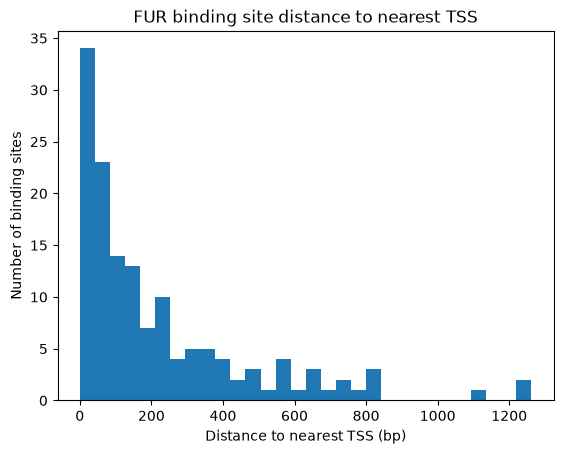

In [ ]:
# RNA polymerase는 Transcription start site에서 먼저 RNA를 합성하기에, 결합부위는 이보다 뒤에 존재하기에 차이는 있을 것이다.
# 하지만, 결합 부위의 start 위치와 TSS간의 거리는 그리 크진 않을 것이기에, x축을 거리(bp)라고 할 때, 앞부분에 데이터가 많이 존재하는
# geometirc dist의 형태를 따를 것이다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TABLE = "../data/reference/ncomms5910_supp_data1_fur_binding_sites.xlsx"
GFF = "../data/reference/ec_annotation_20100903_DHK_cSRNA_with_ortho.gff"

df = pd.read_excel(TABLE, header=1)
df = df.dropna(subset=["Peak"])
df = df[df["Binding Conditiona"].str.contains("R")]
df["center"] = ((df["ChIP-exo Start"] + df["ChIP-exo End"]) / 2).round().astype(int)
# Ex5와 동일하게 데이터 필터링 후 저장하고 binding site의 중심좌표를 계산해서 center column에 새롭게 저장

gff_cols = ["seqname", "source", "feature", "start", "end", "score", "strand", "frame", "attribute"]
genes = pd.read_csv(GFF, sep="\t", names=gff_cols)
genes["tss"] = np.where(genes["strand"] == "+", genes["start"], genes["end"])
tss_sorted = np.sort(genes["tss"].to_numpy()) 
#GFF의 각 컬럼의 헤더 지정, 이후 모든 유전자에 대해 한번에 TSS 계산(strand가 +이면 start, -이면 end)하고 tss_sorted에 정렬해서 저장
# 벡터 연산으로 한번에 처리하는게 더 편함

def nearest_distance(pos, sorted_tss):
    idx = np.searchsorted(sorted_tss, pos)#binding site에서 가장 가까운 TSS 찾기
    candidates = []
    if idx > 0:
        candidates.append(abs(pos - sorted_tss[idx - 1]))
    if idx < len(sorted_tss):
        candidates.append(abs(pos - sorted_tss[idx]))
    return min(candidates)
# 정렬된 tss배열에서 pos를 넣는다면 어디에 들어갈 지를 찾아주는 구문, candidates.append로 양 옆에 있는 TSS와 pos사이의 실제 거리를 저장
# -> TSS-pos의 거리가 더 작은 쪽을 선택해서 binding site에서 가장 가까운 TSS까지의 거리 구함

df["distance_to_tss"] = df["center"].apply(lambda p: nearest_distance(p, tss_sorted))
# bingding site 각각의 중심 좌표에 대해 가장 가까운 TSS까지의 거리를 구한 후 컬럼에 저장

print(f"minimum distance: {df['distance_to_tss'].min()} bp")
print(f"median distance: {df['distance_to_tss'].median()} bp")
print(f"fraction within 500bp of a TSS: {(df['distance_to_tss'] <= 500).mean():.1%}")

"""문제에서 말한 minimum distance, median distance, and fraction of binding sites within 500 bp of a TSS
이때, TSS와 500bp 내에 binding site가 존재하는 비율 -> 조건 설정해서 만족하지 못한 값은 0으로 처리, 만족하는 값만 count 해서 비율로 변환
최소 거리 : 1bp / 중간값 : 131bp / TSS와 500bp내에 존재하는 비율 : 86.7%"""


print(df.loc[df["Transcription Unit"].str.contains("fes",na=False),
             ["Transcription Unit", "ChIP-exo Start", "ChIP-exo End", "distance_to_tss"]])
# 실제로 알려진 FUR 타겟 유전자인 fes를 대상으로 검증, fhuADCB와 같은 단일 유전자를 볼 때는 == "" 으로.

# Cross-check: compare against the paper's own Distance to TSS column, for sites that have one
has_paper_value = df["Distance to TSS"].apply(lambda v: str(v).strip() not in ("-", "nan", ""))
compare = df.loc[has_paper_value, ["Transcription Unit", "distance_to_tss", "Distance to TSS"]].copy()
compare["paper_abs"] = pd.to_numeric(compare["Distance to TSS"]).abs()
compare["diff"] = compare["distance_to_tss"] - compare["paper_abs"]
print(compare.head(10))
print(f"median |difference| vs paper's column: {compare['diff'].abs().median()} bp")
# 논문 테이블의 Distance to TSS 컬럼은 값이 없는 행이 있어서, 이를 필터링하기 위해 전부 str형태로 전환해서 결측치 필터링(True/False series로)
# 값이 실재하는(True) 행들만 골라서 이름, 계산한 거리, 논문 데이터가 제시한 거리만을 남김. 이때 .copy를 써서 잘라낸 결과를 독립된 새 dataframe으로 제시하여 원본 수정 방지
# str로 바꿔둔 값들을 다시 numeric으로 전환, 이후 논문이 제시한 값에서는 방향성을 위해 음수로 제시한 값도 있어서, 비교를 위해 절댓값 부여
# 내가 계산한 거리 - 논문 데이터에서 제시한 거리 = diff 로 새 컬럼으로 저장, 이후 10개의 행만 추출해서 실제 값들이 어떻게 차이나는지 확인.

plt.hist(df["distance_to_tss"], bins=30)
plt.xlabel("Distance to nearest TSS (bp)")
plt.ylabel("Number of binding sites")
plt.title("FUR binding site distance to nearest TSS")
plt.savefig("../data/reference/tss_distance_histogram.png")
plt.show()
# 거리에따른 히스토그램


## 7. Integrative Visualization in MetaScope

So far this module produced three separate results: an **RNA-seq coverage** track (Section 2), a set of **Fur binding sites** (the table from Exercise 5), and a **motif** (Section 5). Each answers part of the FUR story, but the story only comes together when you see them **on the same axis**.

That is what MetaScope is for. In Module 3 you visualized a single ChIP-exo track. Here you'll overlay **three tracks** and read the regulation directly off the screen:

| Track | File | What it shows |
|-------|------|---------------|
| Gene annotation | `ec_annotation_20100903_DHK_cSRNA_with_ortho.gff` | Where the genes are |
| RNA-seq coverage | `rnaseq.gff` (your Exercise 2 output) | How strongly each region is transcribed |
| Fur binding sites | `fur_sites.gff` (you'll build it below) | Where FUR binds |

The biological payoff: at an iron-uptake gene, you should be able to see a **Fur binding site** sitting just upstream **and** ask whether the gene's **RNA-seq signal** is consistent with FUR's role as a repressor.

> As in Module 3, MetaScope runs on **your own computer**, not in the Codespace. Install it from the lab homepage ([sbml-lab.ai](https://sbml-lab.ai)). Produce the GFFs here, download them, then open them locally.

### Exercise 8 — Turn the Binding Sites into a Track

Your RNA-seq track and the annotation are already GFF files. The binding sites, though, are still rows in an Excel table — MetaScope can't read those. Convert them.

Use Claude Code to write a short script that reads the **iron-replete** binding sites (the `R` / `R/S` rows you filtered in Exercise 5) and writes a GFF file `data/reference/fur_sites.gff`, one row per site:

```
NC_000913	furchip	fur_site	<ChIP-exo Start>	<ChIP-exo End>	<S/N ratio>	.	.	name=<Transcription Unit>
```

Two things that matter (both are recurring themes in this course):
- **Chromosome ID must match the other tracks.** Use `NC_000913` in column 1 — the same ID the annotation and the `makegff.py` tracks use — so all tracks line up on the same view.
- **Put the S/N ratio in the score column** so stronger sites can be told apart when you display the track.

Write the script below, run it, and confirm `fur_sites.gff` has roughly one row per iron-replete site (~143).

In [1]:
import pandas as pd

TABLE = "../data/reference/ncomms5910_supp_data1_fur_binding_sites.xlsx"
OUT = "../data/reference/fur_sites.gff"

# Exercise5와 동일한 방법으로 필터링
df = pd.read_excel(TABLE, header=1)
df = df.dropna(subset=["Peak"])
df = df[df["Binding Conditiona"].str.contains("R")]

with open(OUT, "w") as f:
    for _, row in df.iterrows():#필터링 된 column하나씩 GFF 작성 -> 데이터 양이 많아지면 벡터화해서 연산하는게 좋을 듯
        start = int(row["ChIP-exo Start"])
        end = int(row["ChIP-exo End"])
        #start, end를 정수로 변환
        score = row["S/N ratio"]
        # score에 S/N ratio 넣어서 결합 세기를 색/높이로 구분
        name = row["Transcription Unit"] if pd.notna(row["Transcription Unit"]) else row["Peak"]
        f.write(f"NC_000913\tfurchip\tfur_site\t{start}\t{end}\t{score}\t.\t.\tname={name}\n")

print(f"wrote {len(df)} rows to {OUT}")
# 출력 파일 확인 결과, 143개의 행을 출력함


wrote 143 rows to ../data/reference/fur_sites.gff


### Exercise 9 — Overlay Three Tracks and Read the Regulation

On your machine, open MetaScope and load **all three** GFFs (`Ctrl/Cmd+O`): the annotation, `rnaseq.gff`, and `fur_sites.gff`.

1. **Pick a Fur-regulated iron gene.** Use `Ctrl/Cmd+F` to search the annotation, or `Ctrl/Cmd+G` to jump to a coordinate. Good candidates (verified in the lab annotation): **`fepA`** (~609–612 kb), the **`entCEBA`** enterobactin cluster (~624–629 kb), **`fhuA`** (~167 kb), or **`sodB`** (~1,733 kb).
2. **Line up the three tracks.** At your chosen gene, check: is there a **Fur binding site** just upstream? What does the **RNA-seq coverage** look like over the gene body?
3. **Note the RNA-seq condition.** FUR represses iron-uptake genes **when iron is replete**. Whether you expect high or low RNA-seq signal depends on the iron condition of the sample you aligned in Exercise 2 — state which condition it is and reason accordingly. (If you're unsure, that's a `/explain` or a quick check of the GSE54900 sample metadata.)
4. **Adjust the display** so the figure is readable: set distinct track colors (`Ctrl/Cmd+Shift+C`) and heights (`Ctrl/Cmd+Shift+H`), and scale the RNA-seq track so its peaks are visible.
5. **Export** (`Ctrl+Shift+E` → PNG, 300 dpi) as `module4_integrative_metascope.png`.

This exported figure is your Module 4 visualization deliverable.

> **Answer**
>
> **cond에 따른 RNA expression 비교를 하기 위해 사진으로 repleted & depleted 시 RNA 발현량을 같이 나타내었다.Iron depleted는 주황색, repleted는 파란색으로 나타내었다.**
>
> - Gene chosen (name / locus_tag): gene = fepA / locus_tag = b0584, gene = ftnB / locus_tag = b1902
>   본 논문에선 holo-Fur repression/activation을 설명하기 위해 각각의 유전인자를 예시로 들었다.
>
> - Is there a Fur binding site upstream of it? Position: fepA 유전인자는 annotation 확인 시 -strand에 존재한다. 좌표가 큰 쪽 -> 작은 쪽으로 전사가 진행되니, binding site는 upstream에 존재해야 한다. Metascope로 결과 확인 시 upstream에 존재함을 확인할 수 있었다.
>   또한, ftnB의 경우 +strand에 존재하고 위와 반대의 흐름을 통해 큰 좌표 쪽으로 전사가 진행되니 binding site도 upstream에 위치할 것이라는 생각했다. 하지만 TSS와의 거리를 비교하엿을 때, 133bp-였고, 이는 유전자 내부에 존재한다는 뜻인데 metascope를 통해 확인한 결과 유전자 안쪽에 fur site가 존재함을 확인할 수 있었다.
>
> - RNA-seq condition of your sample (iron-replete / iron-depleted): fepA의 위치인 609477부터 611717까지의 RNA 발현량을 repleted와 비교해서 보았을 때, depleted cond에서 발현량이 증가한 것을 볼 수 있다.
>   ftnB의 경우, metascope를 통해 repleted/depleted 조건에서의 발현량을 비교해 본 결과, replet cond에서 발현량이 더 높은 것을 확인할 수 있다.
>   
>
> - Is the gene's RNA-seq signal consistent with FUR repression **under that condition**? Explain.
>   : Iron-repleted 조건에선 iron uptake 관련 유전자인 fepA 유전자는 전사가 억제되어야 한다. 또한, depleted일 경우 FUR가 억제를 못하므로 발현량이 높아지는 모습도 확인할 수 있다. 이는 holo-FUR repression이 일어나는 모습을 보여준다.
>   ftnB의 경우, iron-repleted cond에서 발현량이 조금 높은 모습을 확인할 수 있다. 이는 holo-Fur activation을 보여주는 것으로, FUR는 iron cond에 따라 반응하는 repressor임과 동시에 어떤 유전인자에 대해선 activator가 될 수 있다.
>   하지만, ftnB의 경우 signal이 미세하므로, 생물학적 신호라고 볼 지, noise라고 볼 지 추가적인 판단이 필요하다고 생각한다.
>
> - Attach `module4_integrative_metascope.png`.
>
> **fepA**
> ![iron_repleted_fepA_repressed](../notebooks/module4_integrative_metascope_fepA.png)
>
> **ftnB**
> ![iron_repleted_ftnB_repressed](../notebooks/module4_integrative_metascope_ftnB.png)

### Exercise 10 — Tie It Back to the Motif and the Literature

You now have three lines of evidence at one locus: a **binding site** (the track), a **motif** (Section 5 — is there a Fur box in that site's sequence?), and an **expression level** (the RNA-seq track). Together these are the core of what Seo et al. 2014 reported.

Write a short interpretation (3–5 sentences):
- Does the binding + expression pattern at your gene match FUR acting as an iron-responsive **repressor**?
- Is this **confirmatory** (a known FUR target), or did you land somewhere **unexpected** (FUR's "role beyond iron metabolism," as the paper's title puts it)?
- Use Claude Code to cross-check the gene's function and known FUR regulation — and note anything that *didn't* line up, and how you resolved it.

This is exactly the kind of integrative reading your mini-project (Module 5) will ask you to do independently.

> **Answer**
>
> *(Your 3–5 sentence integrative interpretation — binding + motif + expression, confirmatory vs unexpected, and what you cross-checked.)*
>
> 1. Binding과 발현량 패턴을 보았을 때, iron repleted 조건에서 fepA의 발현이 감소합을 확인했다. 반면, iron-depleted에서 iron uptake에 관한 fepA는 발현량이 증가했다. 이를 통해 FUR의 결합 및 풀림을 통해 gene expression을 조절하는 iron-responsive repressor라 할 수 있다.
>
> 2. fepA 유전인자를 기준으로 한 검증은 이미 Fur의 target gene으로 알려져있는 fepA에 대한 confirmatory conclusion이다. 논문 내용을 보았을 때, FUR는 TCA cycle의 효소를 발현하는 유전인자인 acnA를 iron-replete 조건에서 활성화 하여 철 관련 대사 뿐만 아니라 다른 metabolic pathway에도 영향을 준다는 점을 확인하였음을 알 수 있다. 이는 FUR의 결합부위와 억제 및 활성 대상 인자를 확인함으로써 iron uptake외에 microorganism 내에서 일어나는 다른 대사들에 FUR가 관여할 수 있음을 보여준다.
>
> 3. 
>   - fepA : 외막 수용체(outer membrane receptor) 단백질. 세포 밖에 분비된 siderophore인 enterobactin(철과 결합한 상태)을 세포 안으로 다시 끌어들이는 문/수용체 역할, 철이 부족할 때 필요 -> 기능을 고려했을 때, iron-depleted 조건에서 더 발현되고, repleted 조건에서 억제되는 데이터와 일치한다.
>   
>   - ftnB : 철 저장(iron storage) 관련 단백질로, iron uptake 유전자(fepA, entCEBA 등)와는 반대로 "철이 충분할 때 저장 능력을 늘리는" 역할을 하는 유전자다. -> 기능을 고려했을 때, repleted 조건에서 발현되고, deplted 조건에서 억제되는 데이터와 일치한다.
>   
>   - acnA (aconitate hydratase 1) : TCA 회로 효소(citrate ↔ isocitrate 이성질화 반응 촉매). acnA는 오히려 산화 스트레스/철 결핍 조건에서 유도(induce)되는 편이라, FUR가 일반적인 repressor 패턴과는 다르게 작동하는 대표적 예


## End of Module 4

You have completed:
- Reading and understanding a real ChIP-exo paper (Seo et al. 2014)
- Downloading and running a **paired-end RNA-seq** alignment, and producing a GFF track from it
- Using Biopython to pull binding-site sequences from a reference genome
- Running MEME and interpreting motif output
- Computing TSS distances as a downstream regulatory analysis
- **Overlaying annotation + RNA-seq + Fur binding sites in MetaScope** and reading the regulation integratively (`module4_integrative_metascope.png`)

---

Run `/log` before closing this session.

## Git — Commit Your Work

Every session ends with a commit. Run the commands below in your terminal (not in this notebook).

Write your own commit message following the format: `feat(module4): <what you did>`.  
If you're unsure what to write, ask Claude Code to suggest one based on what you worked on.

In [ ]:
# Run these in the terminal (not here):
# git add notebooks/
# git commit -m "..."   # write your own commit message; use Claude Code to help if needed
# git push
